In [1]:
import sys
from pathlib import Path

sys.path.append(f"{Path().absolute().parent}")

In [2]:
from __future__ import annotations

from MRO_library import *
import plots
from radp.digital_twin.utils.gis_tools import GISTools

### Data Preprocessing

In [3]:
ue_data = pd.read_csv('data/sim_data/UE_Data_20UE_100ticks.csv')
# ue_data = pd.read_csv("data/sim_data/100UE_500Ticks.csv")
# ue_data = ue_data.rename(
#    columns={"lon": "longitude", "lat": "latitude"}
#)  # Delete Later

ue_data

,mock_ue_id,longitude,latitude,tick
0,0,-22.625309,59.806764,0
1,1,119.764151,54.857584,0
2,2,72.095437,-20.253892,0
3,3,-67.548009,-38.100941,0
4,4,59.867089,-83.103930,0
...,...,...,...,...
1995,15,45.564260,42.609846,99
1996,16,132.457280,17.241235,99
1997,17,-101.217659,72.295988,99
1998,18,-16.480045,-26.656397,99


In [4]:
topology = pd.read_csv("data/sim_data/topology.csv")

topology.loc[topology["cell_id"] == "cell_1", "cell_lat"] = -90
topology.loc[topology["cell_id"] == "cell_2", "cell_lat"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lat"] = 90

topology.loc[topology["cell_id"] == "cell_1", "cell_lon"] = -180
topology.loc[topology["cell_id"] == "cell_2", "cell_lon"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lon"] = 180

topology.loc[topology["cell_id"] == "cell_1", "cell_carrier_freq_mhz"] = 2100
topology.loc[topology["cell_id"] == "cell_2", "cell_carrier_freq_mhz"] = 2100
topology.loc[topology["cell_id"] == "cell_3", "cell_carrier_freq_mhz"] = 2100

topology

,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,-90.0,-180.0,cell_1,0,2100
1,0.0,0.0,cell_2,120,2100
2,90.0,180.0,cell_3,240,2100


In [5]:
data = concatenate_ue_to_topology(ue_data, topology)
data = connect_ue_to_all_cells(data, topology)

In [6]:
# Calculating distance and received power
data["distance_km"] = data.apply(
    lambda row: GISTools.get_log_distance(
        row["latitude"], row["longitude"], row["cell_lat"], row["cell_lon"]
    ),
    axis=1,
)
data["cell_rxpower_dbm"] = data.apply(
    lambda row: calculate_received_power(
        row["distance_km"], row["cell_carrier_freq_mhz"]
    ),
    axis=1,
)
# Rename Mock UE ID to UE ID for consistency
data = data.rename(columns={"mock_ue_id": "ue_id"})
data["ue_id"] = data["ue_id"].astype(int)
topology["cell_id"] = topology["cell_id"].str.replace("cell_", "").astype(int)
data["cell_id"] = data["cell_id"].str.extract("(\d+)").astype(int)
data = data.rename(columns={"latitude": "loc_y", "longitude": "loc_x"})
data["relative_bearing"] = data.apply(
    lambda row: GISTools.get_relative_bearing(
        row["cell_az_deg"], row["cell_lat"], row["cell_lon"], row["loc_y"], row["loc_y"]
    ),
    axis=1,
)
# data = data.rename(columns={'cell_rxpower_dbm': 'rsrp_dbm'})
data = add_sinr_column(data)

In [7]:
data.dtypes

ue_id                      int32
loc_x                    float64
loc_y                    float64
tick                     float64
cell_lat                 float64
cell_lon                 float64
cell_id                    int32
cell_az_deg                int64
cell_carrier_freq_mhz      int64
distance_km              float64
cell_rxpower_dbm         float64
relative_bearing         float64
sinr_db                  float64
dtype: object

### Perform Attachment w/ Hyst & TTT

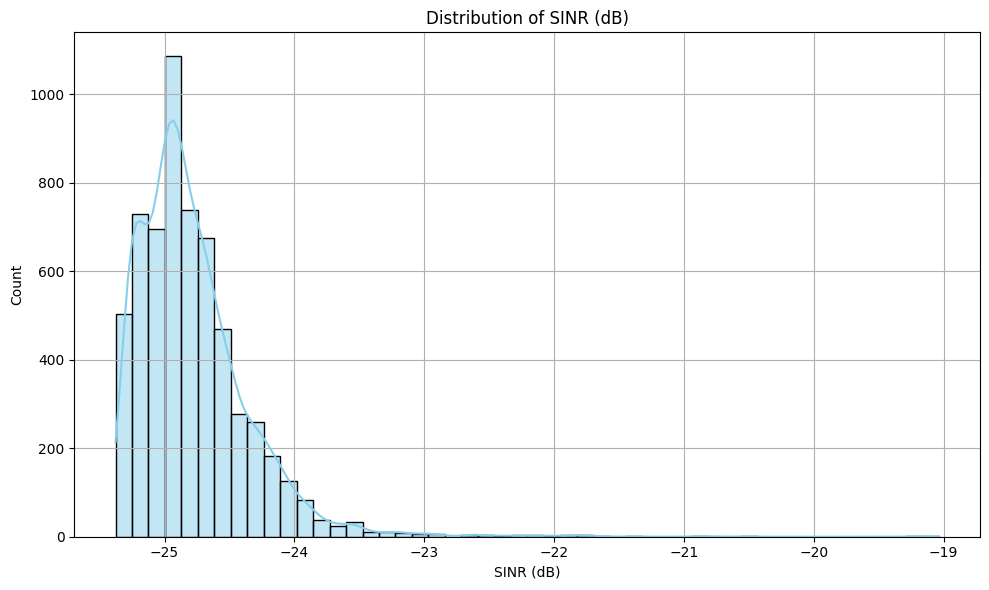

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data["sinr_db"], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribution of SINR (dB)")
plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

#### HyperParameters

In [9]:
hyst = 0.25  # 0<hyst
ttt = 5  # 2<ttt< total ticks
rlf_threshold = -25

In [10]:
attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)

In [11]:
attached_df

,ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,2100.0,15.027772,-99.432278,60.193236,-24.349955
5,1.0,119.764151,54.857584,0.0,90.0,180.0,3.0,240.0,2100.0,15.179563,-99.519571,65.142416,-24.390584
6,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.865016,-99.903196,159.746108,-24.691764
9,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.569455,-99.739854,141.899059,-24.488602
12,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,1.0,0.0,2100.0,13.551107,-98.533881,96.896070,-23.485879
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,15.0,45.564260,42.609846,99.0,90.0,180.0,3.0,240.0,2100.0,15.478569,-99.689002,77.390154,-24.585311
16,16.0,132.457280,17.241235,99.0,90.0,180.0,3.0,240.0,2100.0,15.907303,-99.926317,102.758765,-24.846477
17,17.0,-101.217659,72.295988,99.0,90.0,180.0,3.0,240.0,2100.0,14.493946,-99.118118,47.704012,-24.031577
18,18.0,-16.480045,-26.656397,99.0,0.0,0.0,2.0,120.0,2100.0,15.054748,-99.447856,101.787576,-24.344752


In [12]:
mro_metric = calculate_mro_metric(attached_df)
print(f"Switches: {count_switches(attached_df)}, RLF: {count_rlf(attached_df)}")
print(f"MRO Score: {mro_metric}")

Switches: 40, RLF: 0
MRO Score: 98.0


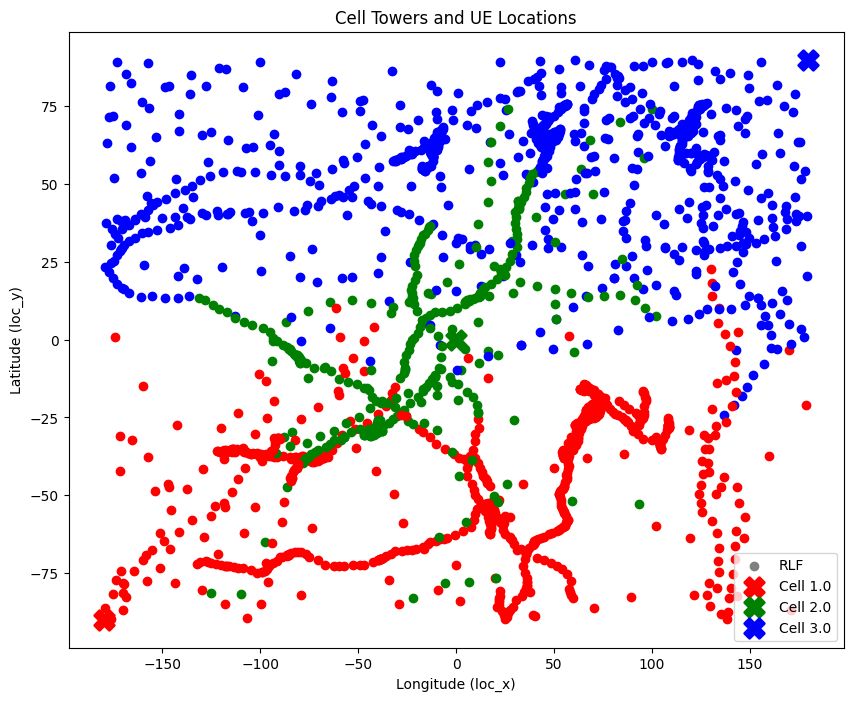

In [13]:
plots.plot_scatter2(attached_df, topology)

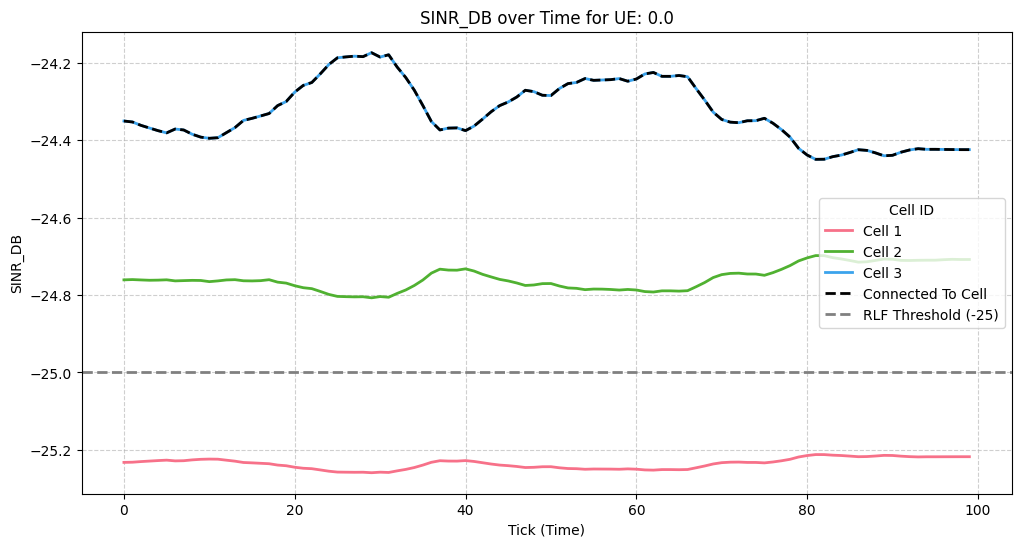

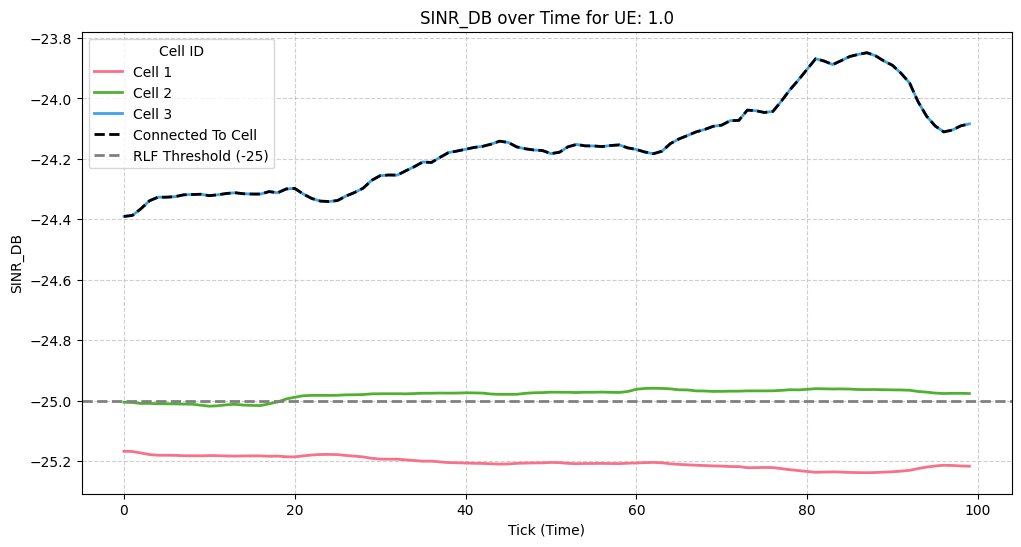

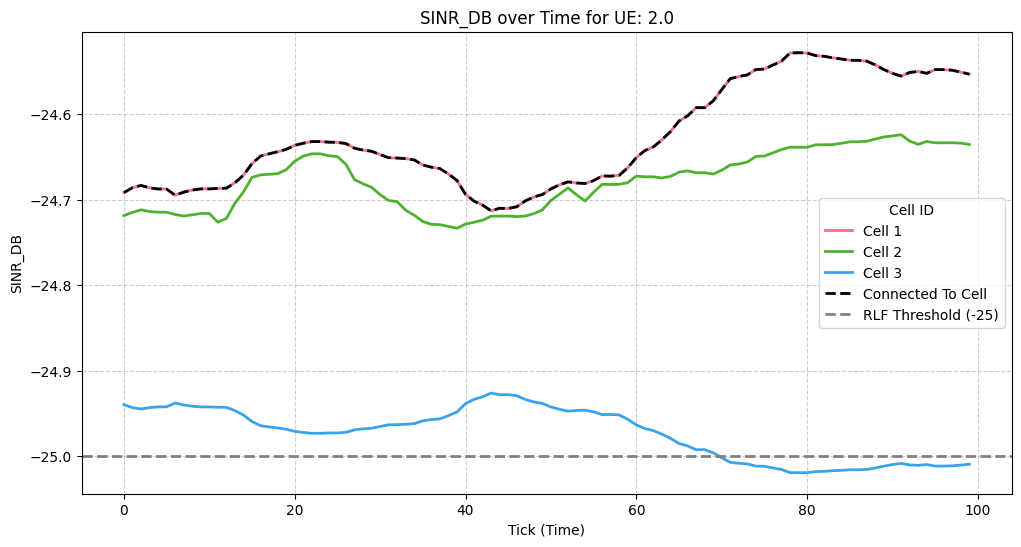

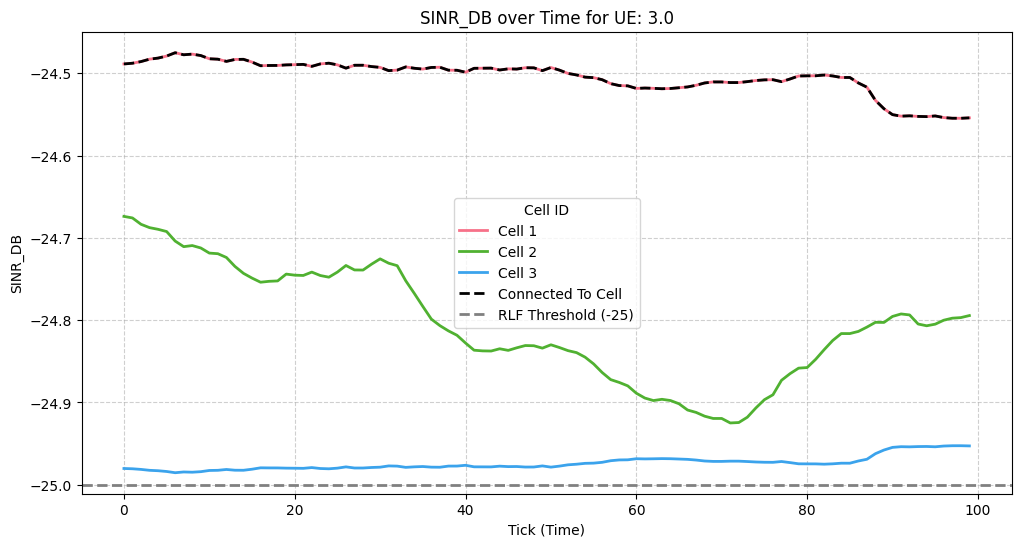

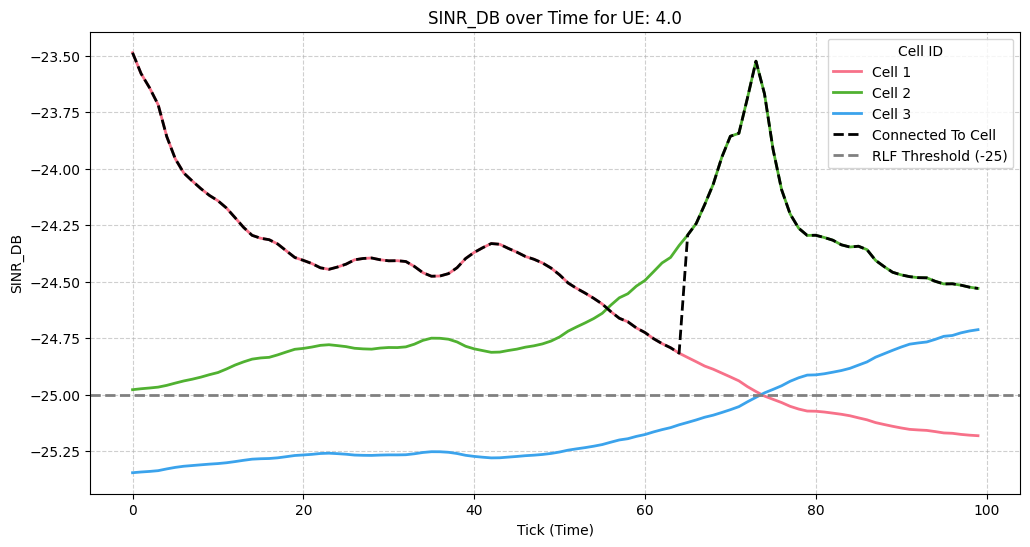

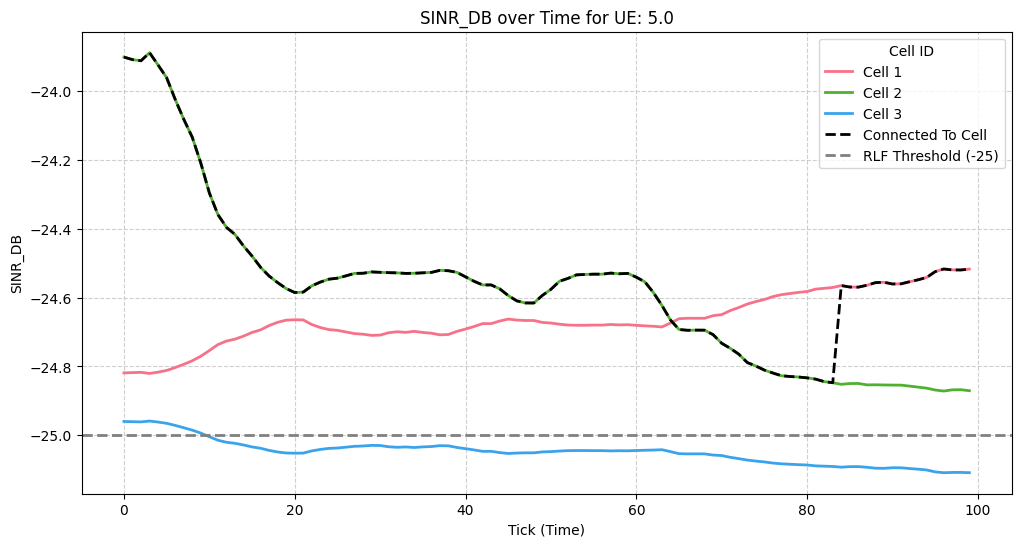

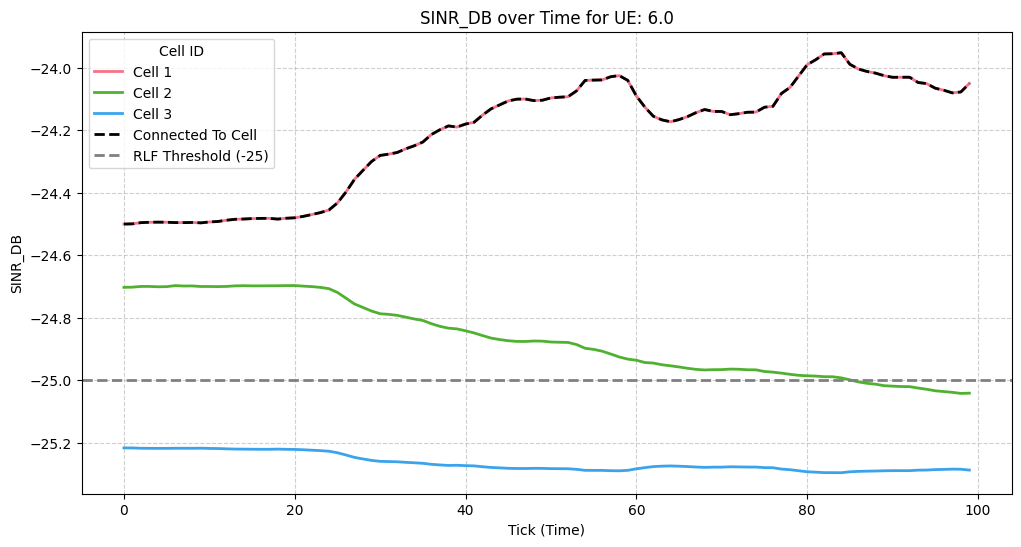

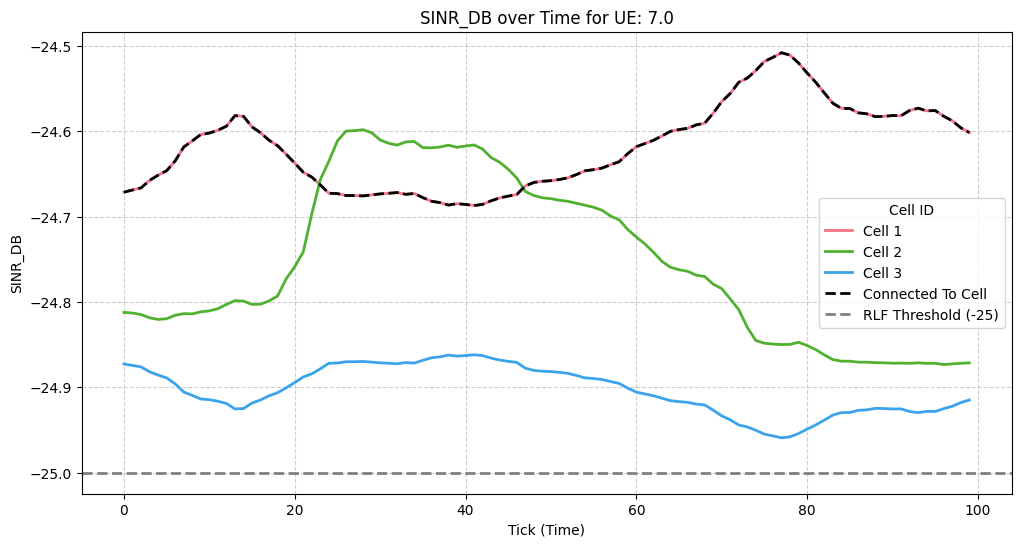

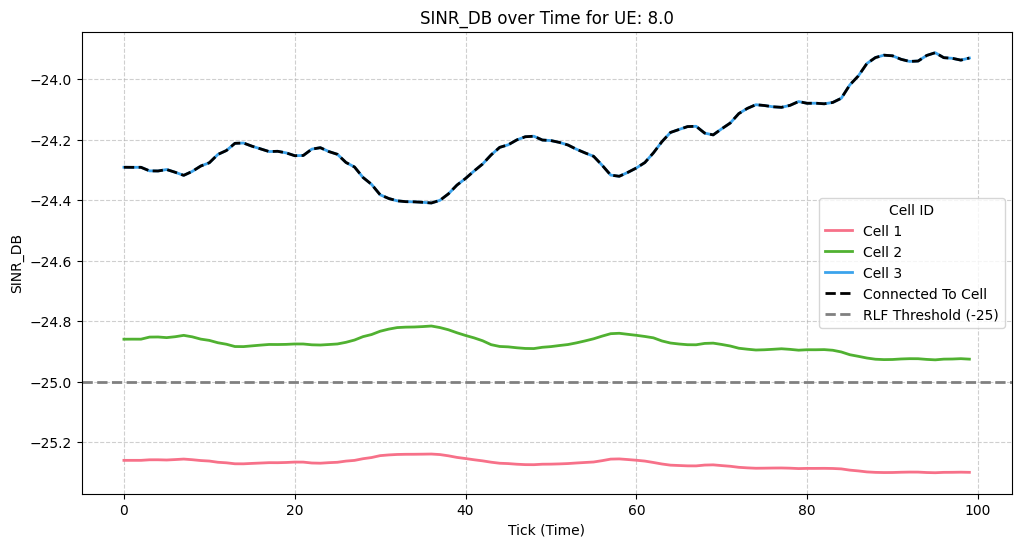

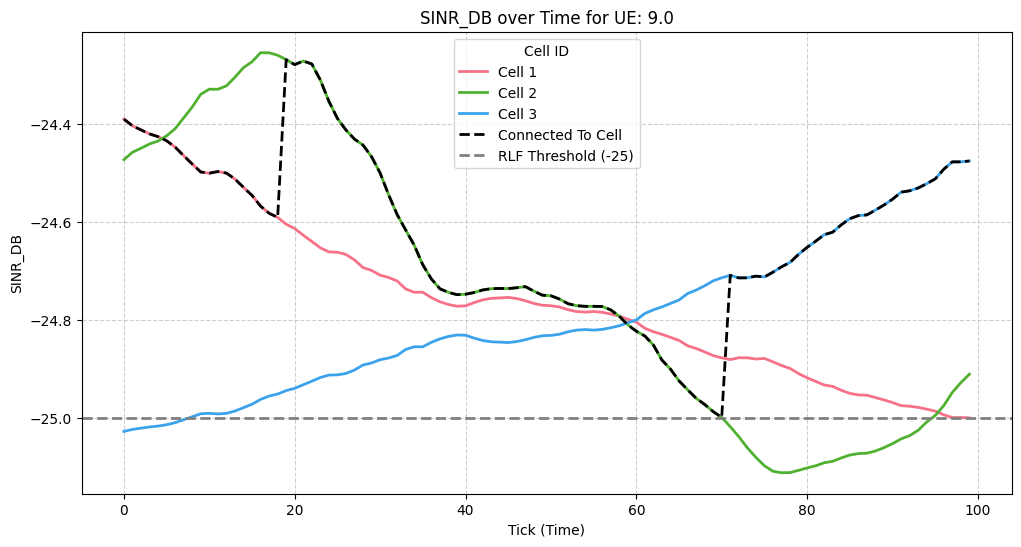

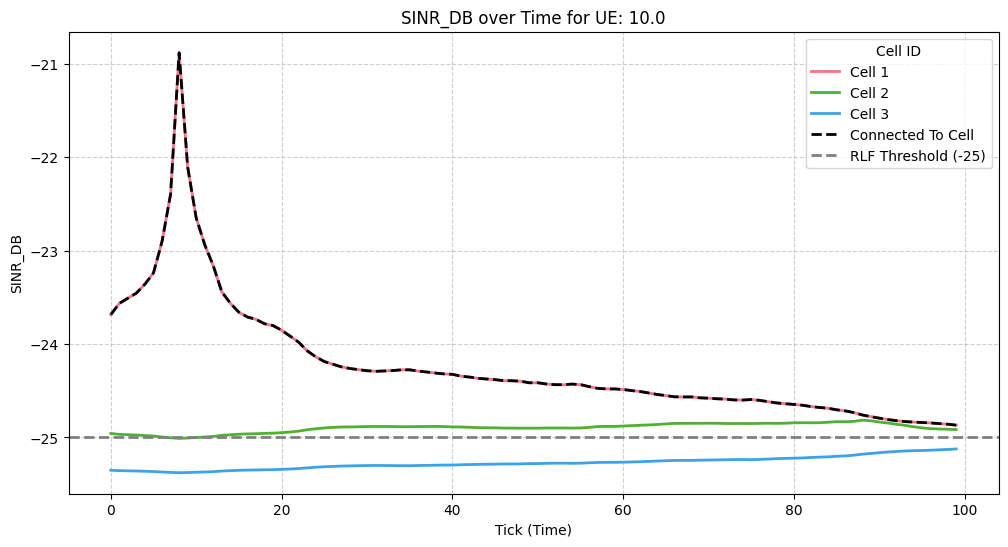

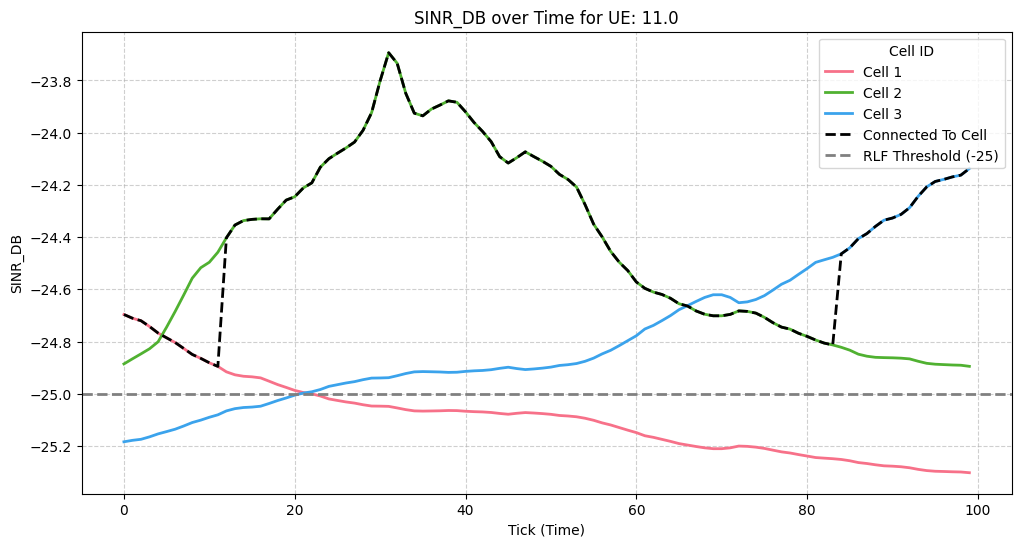

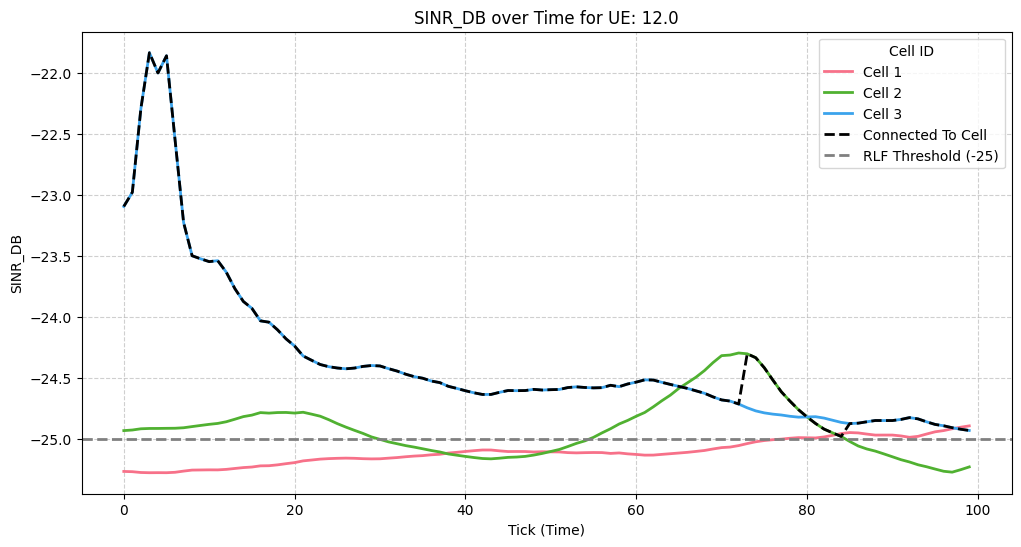

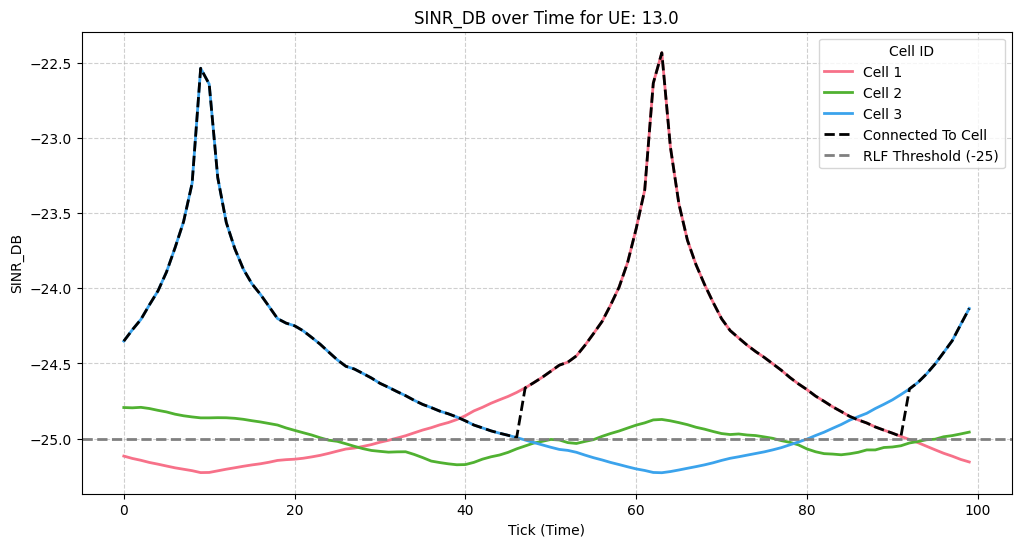

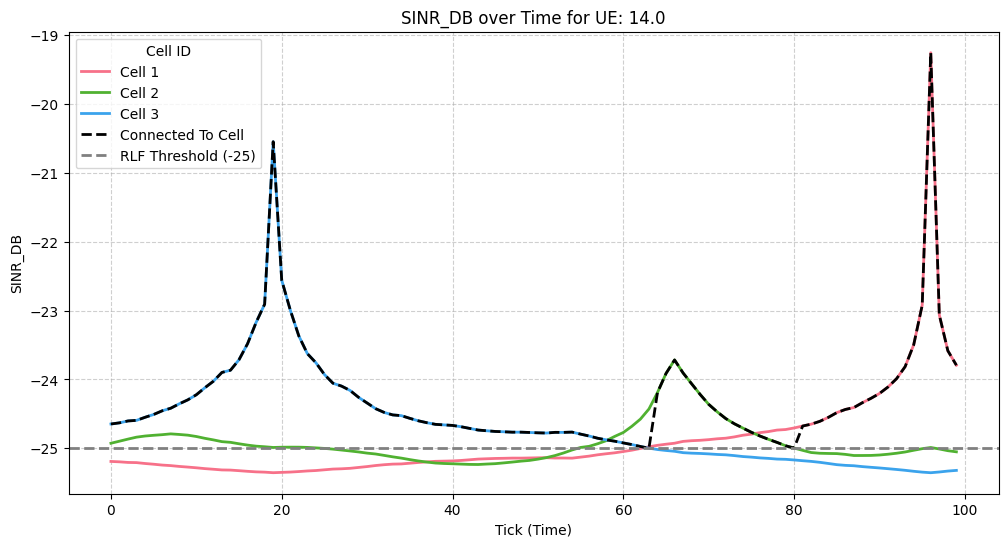

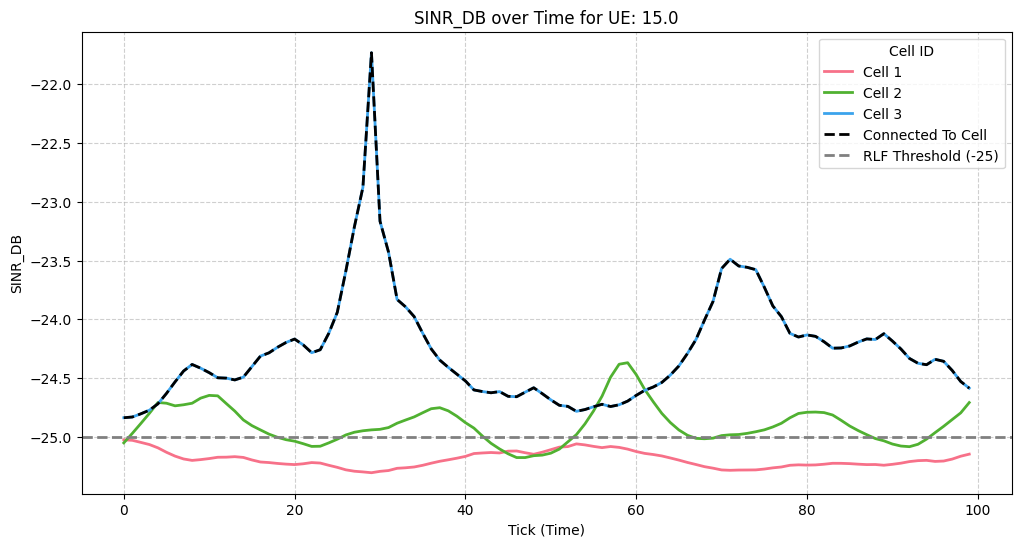

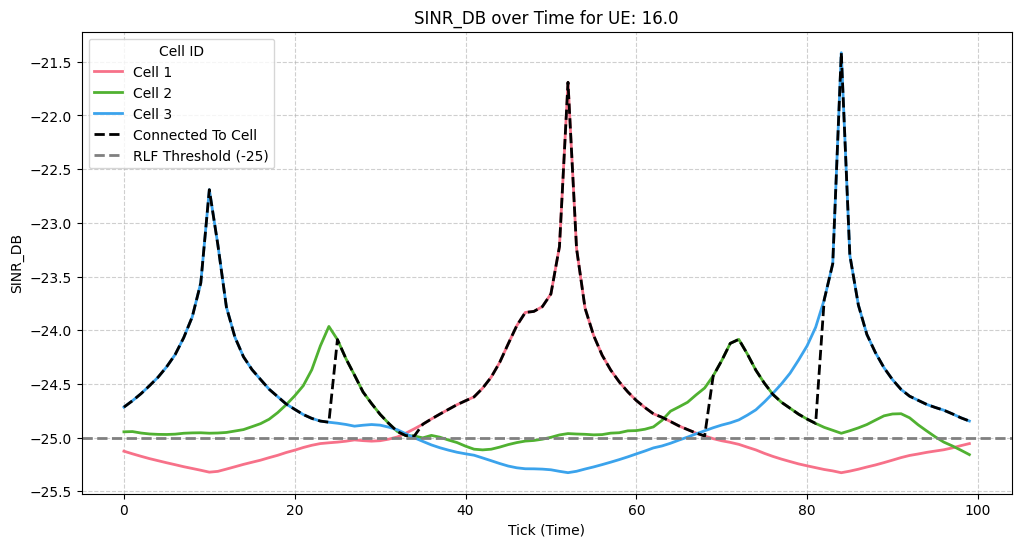

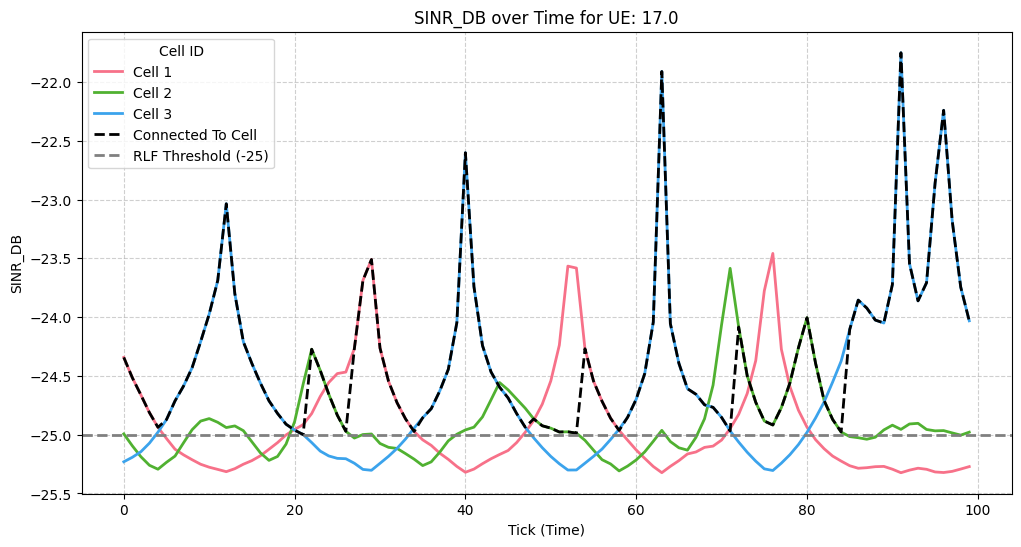

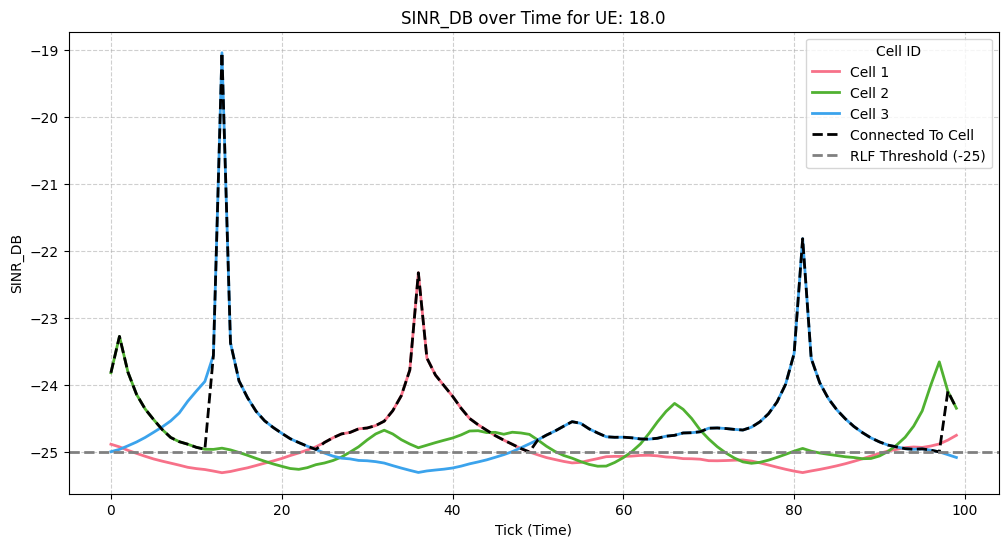

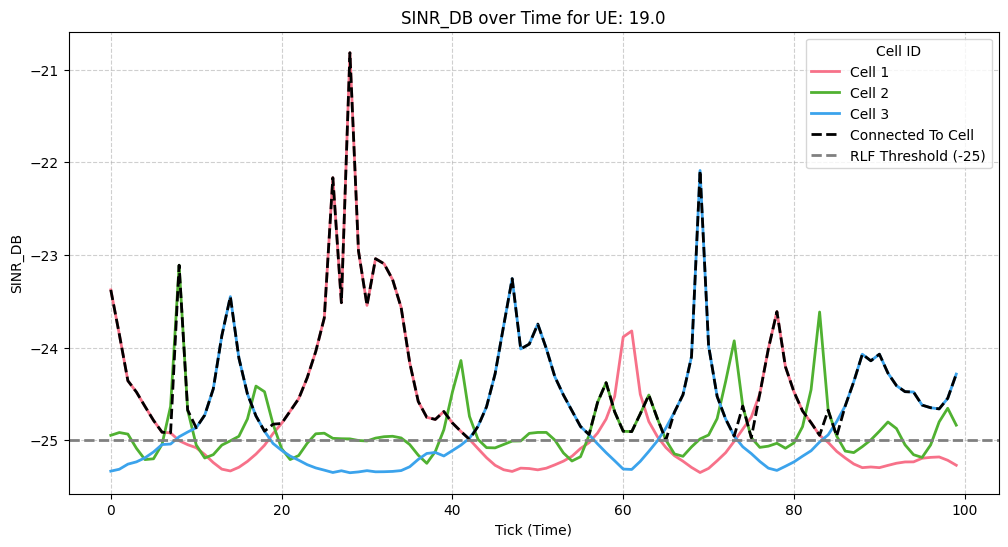

In [14]:
ue_ids = attached_df['ue_id'].unique()
for i in ue_ids:
    plots.plot_sinr_over_time(attached_df, data, i, rlf_threshold)
    # plots.individual_scatter_plot(attached_df, data, i)

## Optimizing Hyst & TTT

In [15]:
max_diff = find_hyst_diff(attached_df)
num_ticks = attached_df["tick"].nunique()
print(f"Max Hyst Diff: {max_diff}\nNum Ticks: {num_ticks}")

Max Hyst Diff: 6.059709840874888
Num Ticks: 100


In [32]:
epochs = 100

hyst_range = [0, max_diff]
ttt_range = [2, num_ticks+1]
score = pd.DataFrame(columns=["hyst", "ttt", "score"])

### Random Sampling

In [33]:
# Define the header for the columns
header = f"{'Epoch':<6} {'Hyst':<14} {'TTT':<6} {'MRO Metric':<12}"
print(header)
print("-" * len(header))  # Automatically match the length of the header

score.loc[len(score)] = [hyst, ttt, mro_metric]
# Loop over the epochs
for i in range(epochs):
    while True:
        hyst = np.random.uniform(hyst_range[0], hyst_range[1])
        ttt = np.random.randint(ttt_range[0], ttt_range[1])
        if ttt not in score["ttt"].values or hyst not in score["hyst"].values:
            break

    # Perform attachment and calculate MRO Metric
    attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)
    mro_metric = calculate_mro_metric(attached_df)

    # Print the data, ensuring proper alignment with the header
    print(f"{i:<6} {hyst:<14.10f} {ttt:<6} {mro_metric:<12.6f}")

    # Store the data in the score DataFrame
    score.loc[len(score)] = [hyst, ttt, mro_metric]


Epoch  Hyst           TTT    MRO Metric  
-----------------------------------------
0      5.8972135074   56     97.850000   
1      1.5543756867   14     98.150000   
2      2.4891637301   79     97.200000   
3      2.0978034885   83     97.200000   
4      4.1212996959   34     98.000000   
5      1.1802748878   84     97.200000   
6      3.8485210008   14     98.150000   
7      4.1953617181   38     98.000000   
8      5.3516511364   4      98.350000   
9      0.4108947098   67     97.450000   
10     4.9517132864   33     98.050000   
11     3.3477726512   75     97.300000   
12     3.0833654649   31     98.050000   
13     5.3311136222   43     97.950000   
14     4.1274619384   32     98.050000   
15     4.6329895999   85     97.200000   
16     5.2865387730   45     97.950000   
17     2.3184496902   12     98.150000   
18     2.0422603834   90     97.200000   
19     4.0456134377   44     97.950000   
20     2.3271406908   57     97.850000   
21     2.6519237426   37     98.00

In [34]:
score.loc[score["score"].idxmax()]

hyst      5.351651
ttt       4.000000
score    98.350000
Name: 9, dtype: float64

In [35]:
plots.plot_3d_hyst_ttt_score(score)

### Baysian Optimization

In [36]:
from skopt import gp_minimize

# Define the objective function for Bayesian Optimization
def objective(params):
    hyst, ttt = params
    # Perform attachment with the current hyst, ttt
    attached_df = perform_attachment_hyst_ttt(data, hyst, int(ttt), rlf_threshold)
    # Calculate the MRO metric
    mro_metric = calculate_mro_metric(attached_df)
    # Return the negative MRO metric because we want to maximize it

    print(f"Testing Hyst: {hyst:.10f}, TTT: {ttt}, MRO Metric: {mro_metric:.6f}")
    score.loc[len(score)] = [hyst, ttt, mro_metric]

    return -mro_metric

In [37]:
# Define the search space for hyst and ttt
hyst_range = [0, max_diff]
ttt_range = [2, num_ticks + 1]

# Define the bounds for the optimizer
space = [
    (hyst_range[0], hyst_range[1]),  # Bound for hyst
    (ttt_range[0], ttt_range[1])     # Bound for ttt
]

score = pd.DataFrame(columns=["hyst", "ttt", "score"])

In [38]:
# Run Bayesian Optimization
result = gp_minimize(objective,                  # The objective function
                     space,                      # The search space
                     n_calls=epochs,             # Number of iterations
                     random_state=9,            # For reproducibility
                     verbose=True)               # Print optimization progress

# After optimization, print the best found parameters
best_hyst, best_ttt = result.x
best_mro_metric = -result.fun  # Negate back to get the maximum MRO metric

print(f"Optimized Hyst: {best_hyst:.10f}, Optimized TTT: {best_ttt}, MRO Metric: {best_mro_metric:.6f}")

Iteration No: 1 started. Evaluating function at random point.
Testing Hyst: 2.2085280500, TTT: 51, MRO Metric: 97.850000
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 9.9615
Function value obtained: -97.8500
Current minimum: -97.8500
Iteration No: 2 started. Evaluating function at random point.
Testing Hyst: 0.0457089697, TTT: 33, MRO Metric: 98.000000
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 12.2231
Function value obtained: -98.0000
Current minimum: -98.0000
Iteration No: 3 started. Evaluating function at random point.
Testing Hyst: 0.0807275288, TTT: 89, MRO Metric: 97.200000
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 4.1692
Function value obtained: -97.2000
Current minimum: -98.0000
Iteration No: 4 started. Evaluating function at random point.
Testing Hyst: 0.8333726213, TTT: 16, MRO Metric: 98.150000
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 13.8013
Function value obtained: -98.1500


d:\Anaconda\envs\.venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning:

The objective has been evaluated at point [6.059709840874888, 2] before, using random point [1.5570195090578434, 69]



Testing Hyst: 1.5570195091, TTT: 69, MRO Metric: 97.300000
Iteration No: 91 ended. Search finished for the next optimal point.
Time taken: 7.0445
Function value obtained: -97.3000
Current minimum: -98.3500
Iteration No: 92 started. Searching for the next optimal point.
Testing Hyst: 2.0779041813, TTT: 2, MRO Metric: 98.350000
Iteration No: 92 ended. Search finished for the next optimal point.
Time taken: 13.0154
Function value obtained: -98.3500
Current minimum: -98.3500
Iteration No: 93 started. Searching for the next optimal point.
Testing Hyst: 6.0597098409, TTT: 40, MRO Metric: 98.000000
Iteration No: 93 ended. Search finished for the next optimal point.
Time taken: 9.9908
Function value obtained: -98.0000
Current minimum: -98.3500
Iteration No: 94 started. Searching for the next optimal point.
Testing Hyst: 6.0597098409, TTT: 11, MRO Metric: 98.150000
Iteration No: 94 ended. Search finished for the next optimal point.
Time taken: 11.8409
Function value obtained: -98.1500
Current m

In [39]:
plots.plot_3d_hyst_ttt_score(score)